In [1]:
import os
from pathlib import Path
import gc

import numpy as np
import matplotlib.pyplot as plt

import keras

import torch
from torch.utils.data import DataLoader, TensorDataset 

from skyrmion_dataset import SKYRMION

os.environ["KERAS_BACKEND"] = "torch"

2025-06-28 20:16:31.725027: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-28 20:16:31.725482: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-28 20:16:31.727922: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-28 20:16:31.734282: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751134591.744794    3834 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751134591.74

In [2]:
fe_sk_transition = np.load("data/test/fe_sk_transition_sub.npz", allow_pickle=True)["arr_0"].tolist()
sk_sp_transition = np.load("data/test/sk_sp_transition_sub.npz", allow_pickle=True)["arr_0"].tolist()

In [3]:
def plot_prediction(dataset, models, base_size=24):

    for D, data in dataset.items():
        images = data["images"][::20]
        b_values = data["b_values"][::20]
        fig, axs = plt.subplots(1, len(images), figsize=(base_size, base_size * len(images)))

        for i, image in enumerate(images):
            axs[i].imshow(image, vmin=0., vmax=1., cmap="RdBu")
            axs[i].set_xlim((0., 200.))
            axs[i].set_ylim((0., 200.))
            axs[i].axis("off")

            for j, (name, model) in enumerate(models.items()):
                axs[i].text(70, 5 + 20 * j, ' '.join([f'{value:.2f}' for value in model.predict(image.reshape((1, 200, 200, 1)))[0]]) + '   ' + name,
                                               color="black", size=10, ha='left',
                                               bbox=dict(facecolor="yellow", edgecolor="black", alpha=.7))
        fig.subplots_adjust(wspace=0.1)  
    plt.show()

In [7]:
model_path = Path("saved_models") / "final" / "sub" / "model5_activation" / "model5-2025-06-17_110126-act=gelu,ear=True,fil=32,hea=sigmoid,los=KLD,pad=valid,per=True,pha=N+c+c,see=5.keras" # CNN gelu
# model_path = Path("saved_models") / "sub" / "best" / "ffn-2025-06-20_195509-act=gelu,dec=plateau,dep=1,dro=0.5,ear=True,fil=64,lab=0.05,lea=0.01,los=focal,pad=valid,per=True,pha=N+c+c,see=5,wei=0.keras"
models = {"test-model": keras.models.load_model(model_path, compile=False)}

In [8]:
def model_comparison(dataset, models, group_size=20, trans=None):
    def transform(image, threshold=0.2):
        return (image > threshold).float()

    for D, data in dataset.items():
        images = torch.tensor(data["images"]).float().to("cpu")
        b_values = np.array(data["b_values"])
        b_unique = np.unique(b_values)
        num_groups = len(b_unique)

        dataloader = DataLoader(TensorDataset(images), batch_size=32, shuffle=False)

        model_preds = {name: [] for name in models}

        for name, model in models.items():  
            with torch.no_grad():
                for batch in dataloader:
                    batch_images = batch[0].to("cpu")
                    preds = model(batch_images).cpu().numpy()
                    model_preds[name].extend(preds)

        fig = plt.figure(figsize=(14, 8))
        gs = fig.add_gridspec(2, num_groups, height_ratios=[1, 1])

        ax1 = fig.add_subplot(gs[0, :num_groups // 2])
        ax2 = fig.add_subplot(gs[0, num_groups // 2:])
        axes = [fig.add_subplot(gs[1, i]) for i in range(num_groups)]

        fig.suptitle(f"D: {D}")

        cmap = plt.colormaps["tab20"]

        for idx, (name, preds) in enumerate(model_preds.items()):
            preds = np.array(preds).reshape(num_groups, group_size, -1)
            # Take only Sk predictions
            preds_sk = preds[:, :, 1]
            mean_preds = preds_sk.mean(axis=1)
            var_preds = preds_sk.var(axis=1)

            color = cmap(idx)

            ax1.plot(b_unique, mean_preds, marker='o', linestyle='-', color=color, label=f"{name}")

            if trans is None:
                ax2.plot(b_unique, var_preds, marker='o', linestyle='-', color=color, label=f"{name}")
            else: 
                if trans == "fe":
                    preds_tr = preds[:, :, 0]
                elif trans == "sp":
                    preds_tr = preds[:, :, 2]
                mean_preds_tr = preds_tr.mean(axis=1)
                var_preds_tr = preds_tr.var(axis=1)
                ax2.plot(b_unique, mean_preds_tr, marker='o', linestyle='-', color=color, label=f"{name}")

        # Adding manually calculated 
        images_tranformed = np.array(list(map(transform, images))).reshape(-1, 20, 200, 200)
        means = images_tranformed.mean(axis=(1, 2, 3))
        variances = images_tranformed.mean(axis=(2, 3)).var(axis=1)
        
        color = cmap(len(model_preds))

        # Trying topological number instead
        Q = data["Q"]
        means = Q[::5]

        # rescale by the last model
        # means /= means[0]
        means /= np.max(means)
        # means *= mean_preds[0]
        means *= np.max(mean_preds)
        variances /= variances[0]
        variances *= var_preds[0]

        ax1.plot(b_unique, means, marker='o', linestyle='-', color=color, label=f"Topological charge")
        # ax1.plot(b_unique, means, marker='o', linestyle='-', color=color, label=f"Calculated")
        # ax2.plot(b_unique, variances, marker='o', linestyle='-', color=color, label=f"Calculated")


        ax1.set_title("Average SK probabilities")
        ax1.set_xlabel("B")
        ax1.set_ylabel("Mean Prediction")
        ax1.grid(True)
        handles, labels = ax1.get_legend_handles_labels()

        if trans is None:
            ax2.set_title("Variances")
            ax2.set_xlabel("B")
            ax2.set_ylabel("Variance of Sk Prediction")
            ax2.grid(True)
            ax2.legend(handles=handles, labels=labels, ncol=3, loc="upper right")
        else:
            ax2.set_title(f"Average {trans.upper()} probabilities")
            ax2.set_xlabel("B")
            ax2.set_ylabel("Mean Prediction")
            ax2.grid(True)
            ax2.legend(handles=handles, labels=labels, ncol=3, loc="upper right")

        sample_images = images[::group_size]
        for i in range(num_groups):
            axes[i].imshow(sample_images[i].cpu().numpy(), vmin=0.0, vmax=1.0, cmap="RdBu")
            axes[i].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

In [28]:
def model_comparison2(dataset, models, group_size=20, trans=None):
    def transform(image, threshold=0.2):
        return (image > threshold).float()

    for D, data in dataset.items():
        images = torch.tensor(data["images"]).float().to("cpu")
        b_values = np.array(data["b_values"])
        b_unique = np.unique(b_values)
        num_groups = len(b_unique)

        dataloader = DataLoader(TensorDataset(images), batch_size=32, shuffle=False)

        model_preds = {name: [] for name in models}

        for name, model in models.items():  
            with torch.no_grad():
                for batch in dataloader:
                    batch_images = batch[0].to("cpu")
                    preds = model(batch_images).cpu().numpy()
                    model_preds[name].extend(preds)

        fig = plt.figure(figsize=(14, 16))
        gs = fig.add_gridspec(2, num_groups, height_ratios=[1, 3])

        ax1 = fig.add_subplot(gs[0, :num_groups])
        axes = [fig.add_subplot(gs[1, i]) for i in range(num_groups)]

        cmap = plt.colormaps["tab20"]

        for idx, (name, preds) in enumerate(model_preds.items()):
            preds = np.array(preds).reshape(num_groups, group_size, -1)
            # Take only Sk predictions
            preds_sk = preds[:, :, 1]
            mean_preds = preds_sk.mean(axis=1)
            var_preds = preds_sk.var(axis=1)

            color = cmap(idx)

            ax1.plot(b_unique, mean_preds, marker='o', linestyle='-', color=color, label=f"{name}")


        # Adding manually calculated 
        images_tranformed = np.array(list(map(transform, images))).reshape(-1, 20, 200, 200)
        means = images_tranformed.mean(axis=(1, 2, 3))
        variances = images_tranformed.mean(axis=(2, 3)).var(axis=1)
        
        color = cmap(len(model_preds))

        # Trying topological number instead
        Q = data["Q"]
        means = Q[::5]

        # rescale by the last model
        # means /= means[0]
        means /= np.max(means)
        # means *= mean_preds[0]
        means *= np.max(mean_preds)

        fig.suptitle(f"D: {D}", fontsize=24)

        ax1.plot(
            b_unique, means,
            marker='o',
            linestyle='-',
            color=color,
            label="Topological charge"
        )

        ax1.set_title("Average SK probabilities", fontsize=20)
        ax1.set_xlabel("B", fontsize=18)
        ax1.set_ylabel("Mean Prediction", fontsize=18)

        ax1.set_ylim(-0.1, 1.1)

        ax1.grid(True)

        ax1.tick_params(axis='both', which='major', labelsize=16)

        ax1.legend(fontsize=16)
        sample_images = images[::group_size]
        for i in range(num_groups):
            axes[i].imshow(sample_images[i].cpu().numpy(), vmin=0.0, vmax=1.0, cmap="RdBu")
            axes[i].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.legend()
        plt.show()

        break

In [5]:
def fe_image(dataset, group_size=20):

    def transform(image, threshold=0.2):
        return (image > threshold).float()

    for D, data in dataset.items():
        images = torch.tensor(data["images"]).float().to("cpu")
        b_values = np.array(data["b_values"])
        b_unique = np.unique(b_values)
        num_groups = len(b_unique)

        fig, axs = plt.subplots(2, num_groups, figsize=(14, 8))

        fig.suptitle(f"D: {D}")


        for col, img in enumerate(images[::group_size]):
            axs[0, col].imshow(img, vmin=0., vmax=1., cmap="RdBu")
            axs[0, col].axis("off")
            transformed_img = transform(img)
            if col == 0:
                ref_density = transformed_img.mean()
            rel_density = transformed_img.mean() / ref_density
            axs[1, col].imshow(transformed_img, vmin=0., vmax=1., cmap="RdBu")
            axs[1, col].text(70, 180, f"{rel_density:.3f}", 
                            color="black", size=10, ha='left',
                            bbox=dict(facecolor="yellow", edgecolor="black", alpha=.7))
            axs[1, col].axis("off")


        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()    


In [6]:
import torch.nn.functional as F
def sp_image(dataset, group_size=20):

    def transform(image):
        threshold = torch.quantile(image, 0.1)
        # threshold = 0.2 * image.max()
        return (image < threshold).float()

    def create_diagonal_filter(n, filter="spiral"):
        """Creates an n x n filter with fading values from main diagonal."""
        filt = torch.zeros((n, n))
        if filter == "spiral":
            for i in range(n):
                for j in range(n):
                    distance = abs(i - j)
                    filt[i, j] = 1.0 - (distance / (n - 1))  # linearly fade
            return filt
        
        elif filter == "skyrmion":
            center = (n - 1) / 2
            for i in range(n):
                for j in range(n):
                    distance = ((i - center) ** 2 + (j - center) ** 2) ** 0.5
                    max_dist = (2 * (center**2)) ** 0.5
                    filt[i, j] = 1.0 - (distance / max_dist)
            return filt
        
    def rotate_filter(filt, degrees=90):
        """Rotate the filter by degrees (default is 90 degrees)."""
        k = degrees // 90
        return torch.rot90(filt, k, [0, 1])

    def apply_filter_multiple_times(img, filt, times=1, padding_mode='circular'):
        """Apply a filter multiple times to an image with optional padding mode."""
        img = img.unsqueeze(0).unsqueeze(0)  # add batch and channel dims
        filt = filt.unsqueeze(0).unsqueeze(0)  # out_channels=1, in_channels=1

        pad = filt.shape[-1] // 2
        for _ in range(times):
            img = F.pad(img, (pad, pad, pad, pad), mode=padding_mode)
            img = F.conv2d(img, filt)
            # img = torch.Tensor(transform(img))
        return img.squeeze()
    
    def compute(img):
        filt1 = create_diagonal_filter(5, filter="skyrmion")
        filt2 = rotate_filter(filt1)

        result1 = apply_filter_multiple_times(img, filt1, times=2)
        result2 = apply_filter_multiple_times(img, filt2, times=2)

        return transform(result1 + result2)
        

    for D, data in dataset.items():
        images = torch.tensor(data["images"]).float().to("cpu")
        b_values = np.array(data["b_values"])
        b_unique = np.unique(b_values)
        num_groups = len(b_unique)

        fig, axs = plt.subplots(2, num_groups, figsize=(14, 8))

        fig.suptitle(f"D: {D}")


        for col, img in enumerate(images[::group_size]):
            axs[0, col].imshow(img, vmin=0., vmax=1., cmap="RdBu")
            axs[0, col].axis("off")
            transformed_img = compute(img)

            density = transformed_img.mean()
            axs[1, col].imshow(transformed_img, vmin=0., vmax=1., cmap="RdBu")
            axs[1, col].text(70, 180, f"{density:.3f}", 
                            color="black", size=10, ha='left',
                            bbox=dict(facecolor="yellow", edgecolor="black", alpha=.7))
            axs[1, col].axis("off")


        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

In [ ]:
fe_image(fe_sk_transition)

In [ ]:
sp_image(sk_sp_transition)

In [7]:
from pathlib import Path
import re


def load_models_from_folder(folder_path, filter=None, fullname=False):
    models = {}

    model_files = [f for f in Path(folder_path).glob("*.keras")]

    for file in model_files:
        filename = file.stem

        if fullname:
            model_id = filename
        else:
            model_name = str(filename).split("-")[0]

            match = re.search(r"aug=([^,]+)", filename)
            aug = match.group(1) if match else "N"  

            match = re.search(r"pha=([^,]+)", filename)
            phase_aug = match.group(1) if match else "N-N-N"

            model_id = f"{model_name}-{aug}-{phase_aug}"

        models[model_id] = keras.models.load_model(file, compile=False)

    if filter is not None:
        models = {key: value for key, value in models.items() if filter in key}

    base_model_keys = [key for key in models.keys() if '-' not in key]
    non_base_model_keys = [key for key in models.keys() if '-' in key]

    sorted_keys = sorted(non_base_model_keys) + sorted(base_model_keys)

    sorted_models = {k: models[k] for k in sorted_keys}

    return sorted_models



In [8]:
path = Path("saved_models") / "sub" / "new_augment" 
models = load_models_from_folder(folder_path=path)
models

W0000 00:00:1750455777.497496  360434 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


ValueError: A total of 3 objects could not be loaded. Example error message for object <Dense name=dense_13, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(64, 64), Received: value.shape=(64, 3). Target variable: <Variable path=dense_13/kernel, shape=(64, 64), dtype=float32, value=[[ 0.19044845 -0.05662495  0.1589744  ...  0.03580235 -0.0116699
   0.16873325]
 [ 0.20159094  0.06322901  0.21489729 ...  0.13863806 -0.10107822
   0.06063972]
 [-0.12149988  0.14207016 -0.13998692 ... -0.14611891  0.03075282
   0.04692046]
 ...
 [-0.15105453  0.15402834  0.09731792 ... -0.05493841 -0.10410459
  -0.1896644 ]
 [ 0.02317891  0.00945146 -0.06122395 ...  0.03946824 -0.02231686
  -0.00772946]
 [-0.21237223 -0.15344551 -0.13696894 ...  0.18224095 -0.1454986
   0.17799012]]>

List of objects that could not be loaded:
[<Dense name=dense_13, built=True>, <Dense name=dense_14, built=True>, <Dense name=dense_15, b

In [ ]:
# path = Path("saved_models") / "sub" / "new_augment" 
# models = load_models_from_folder(folder_path=path)
keep = [
    # 'cbam-t+c+N+N+c-N+c+c',
    'model5-N-N+N+N',
    # 'model5-c-N+c+c',
    'model5-m-N+N+N',
    # 'model5-m-N+c+c',
    # 'model5-t+c+N+N+m-N+N+N',
    'model5-t+c+N+N+m-N+c+c',
]
models = {
    key: model for key, model in models.items() if key in keep
}
model_comparison(dataset=fe_sk_transition, models=models, trans="sp")
model_comparison(dataset=sk_sp_transition, models=models, trans="fe")

In [ ]:
path = Path("saved_models") / "25_04" / "in-phase-aug"
models = load_models_from_folder(folder_path=path)
model_comparison(dataset=fe_sk_transition, models=models, trans="sp")
model_comparison(dataset=sk_sp_transition, models=models, trans="fe")

/tmp/ipykernel_3834/3585108064.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


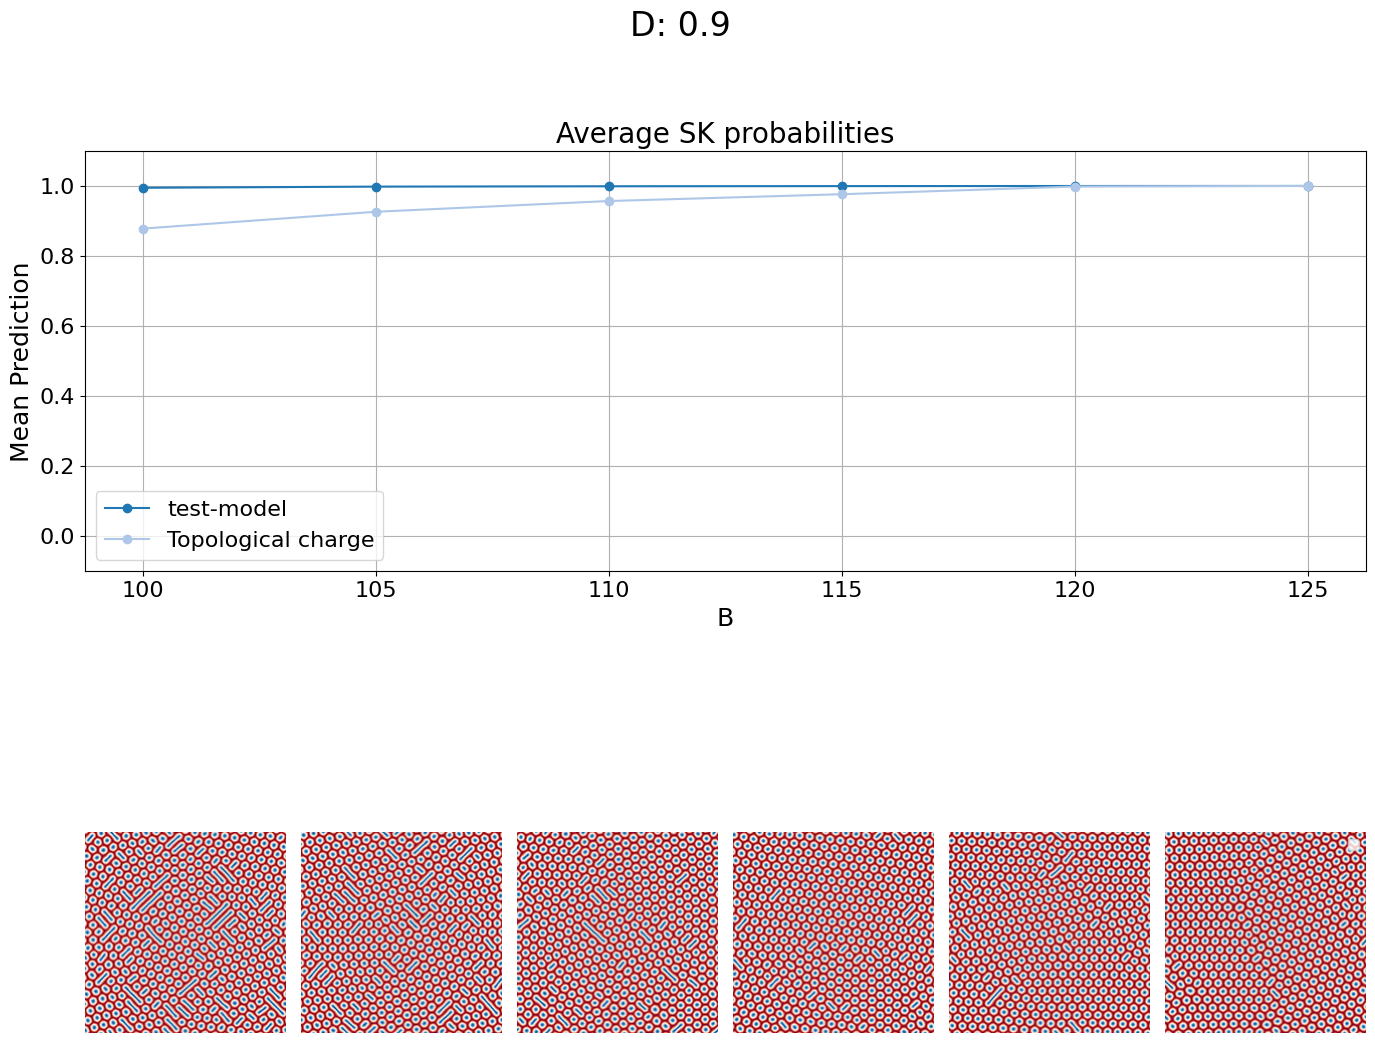

In [29]:
model_comparison2(dataset=sk_sp_transition, models=models)

In [ ]:
model_comparison(dataset=sk_sp_transition, models=models)

In [ ]:
path = Path("saved_models") / "sub_comparison" / "comparison" 
models = load_models_from_folder(folder_path=path, filter="ffn")
model_comparison(dataset=fe_sk_transition, models=models)
model_comparison(dataset=sk_sp_transition, models=models)

In [ ]:
path = Path("saved_models") / "sub_comparison" / "comparison" 
models = load_models_from_folder(folder_path=path, filter="resnet")
# model_comparison(dataset=fe_sk_transition, models=models)
# model_comparison(dataset=sk_sp_transition, models=models)

In [ ]:
path = Path("saved_models") / "sub_comparison" / "comparison" 
models = load_models_from_folder(folder_path=path)

# keys = [
#     'model5-t+c+N+N+m',
#     'model5-t+c+N+c+m',
#     'resnet-m',
#     'resnet-t+c+N+N+m',
#     'ffn-t+c+N+c+m',
# ]
# models = {key: value for key, value in models.items() if key in keys}

model_comparison(dataset=fe_sk_transition, models=models)
model_comparison(dataset=sk_sp_transition, models=models)

In [ ]:
path = Path("saved_models") / "25_04" / "head-loss" 
models = load_models_from_folder(folder_path=path, fullname=True, filter="see=7")
model_comparison(dataset=fe_sk_transition, models=models, trans="sp")
model_comparison(dataset=sk_sp_transition, models=models, trans="fe")

In [29]:
#TODO: augment spiral + spiral could be useful for us, 
# We want to explain the outputs on the transition images.
# for FE-SK transition, we can calculate the portion of skyrmion vs ferromagnet, and look if the models are predicting this portion. Think of something similar for SK-sp transition.
# There is a question of micro and macro structure and we can explore it (e.g. different depth or filter size for different branches), maybe analyze the feature maps better
# Implement grad-cam


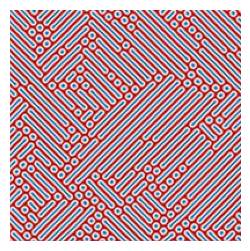

In [8]:
image = sk_sp_transition["1.1"]["images"][::20][3]
SKYRMION.visualize_images(image.reshape(1, 200, 200))

2


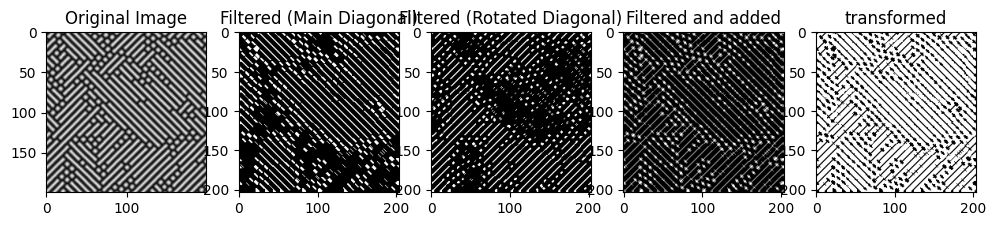

3


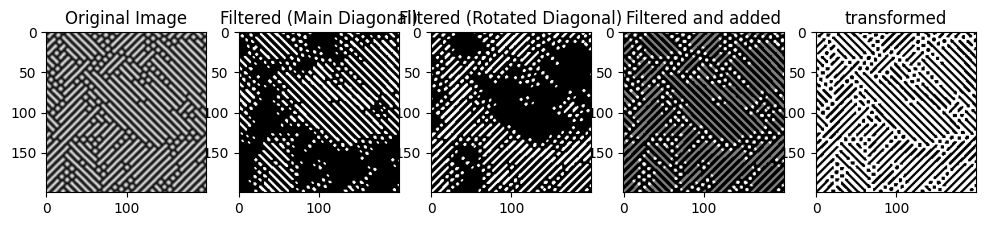

4


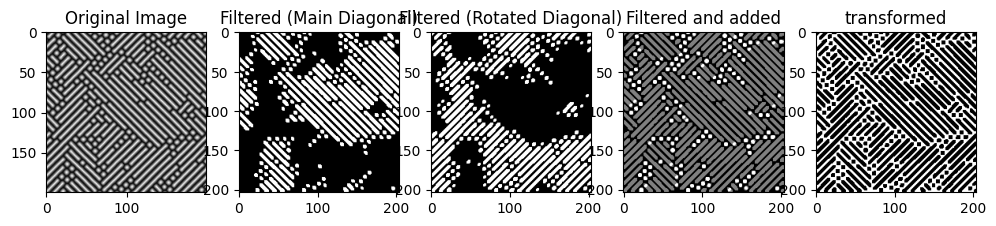

5


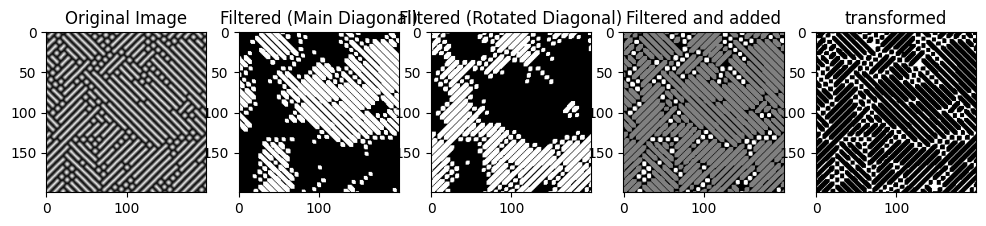

6


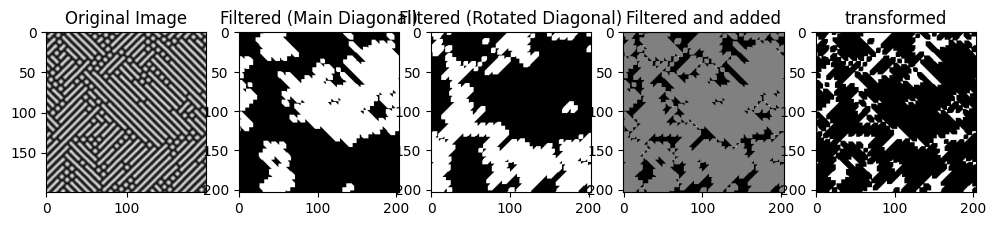

7


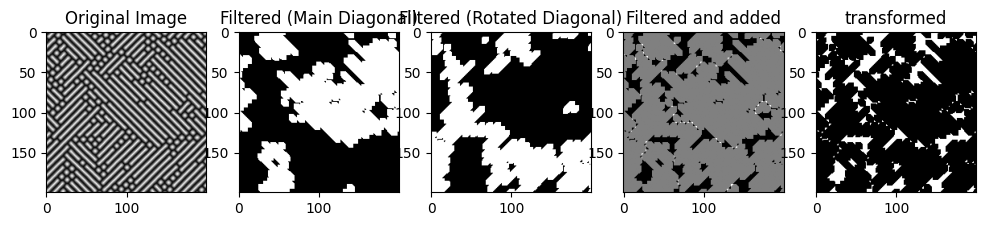

8


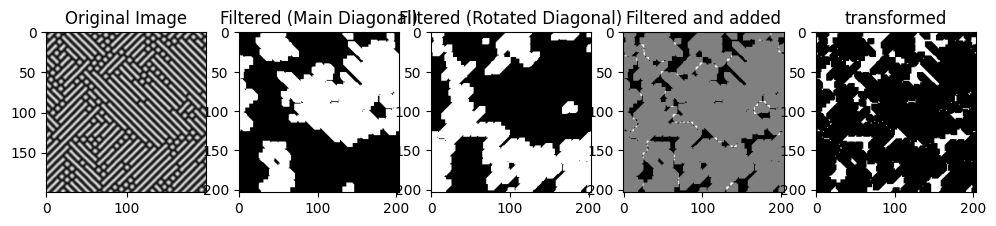

9


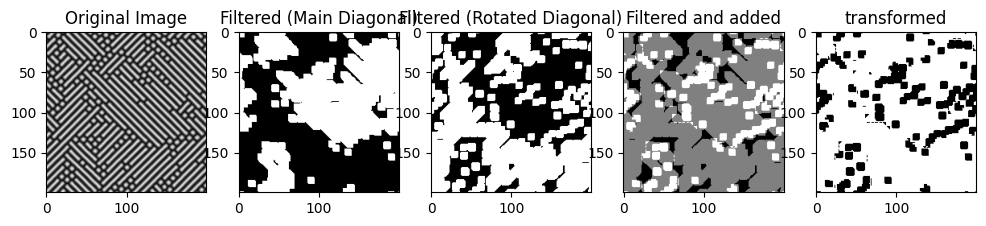

10


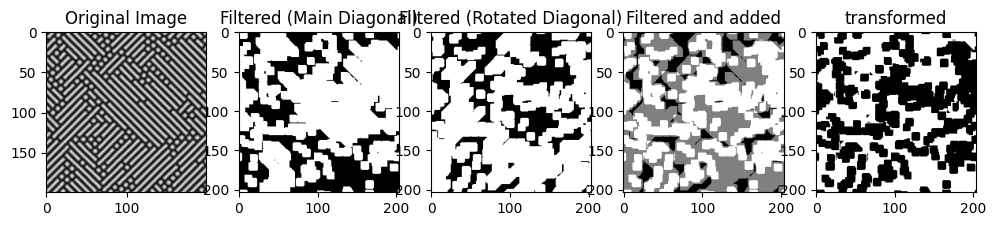

11


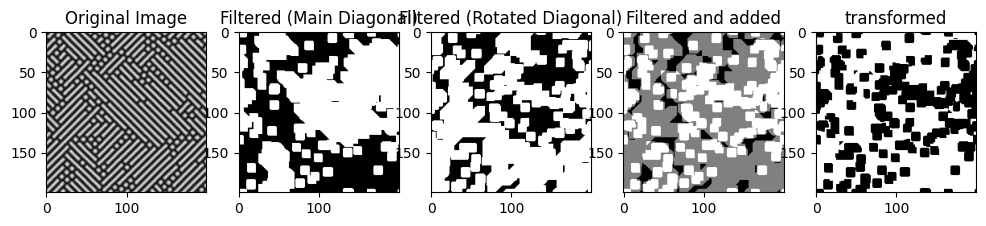

12


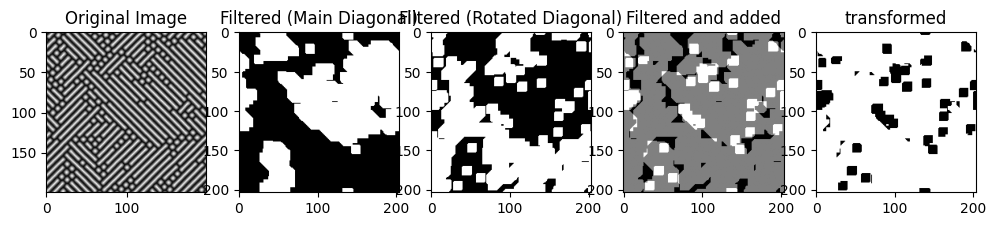

13


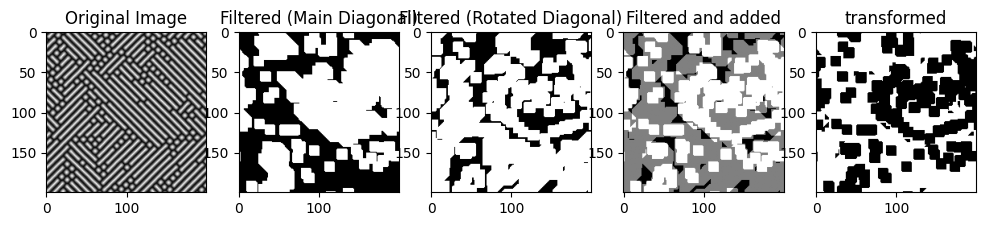

14


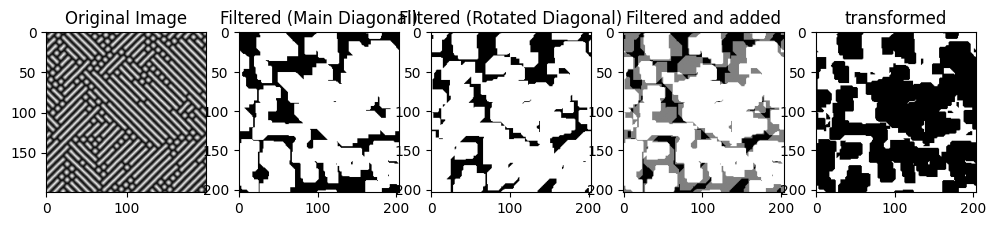

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def transform(image):
    threshold = torch.quantile(image, 0.9)
    return (image < threshold).float()

def create_diagonal_filter(n):
    """Creates an n x n filter with fading values from main diagonal."""
    filt = torch.zeros((n, n))
    for i in range(n):
        for j in range(n):
            distance = abs(i - j)
            filt[i, j] = 1.0 - (distance / (n - 1))  # linearly fade
    return filt

def rotate_filter(filt, degrees=90):
    """Rotate the filter by degrees (default is 90 degrees)."""
    k = degrees // 90
    return torch.rot90(filt, k, [0, 1])

def apply_filter_multiple_times(img, filt, times=1, padding_mode='circular'):
    """Apply a filter multiple times to an image with optional padding mode."""
    img = img.unsqueeze(0).unsqueeze(0)  # add batch and channel dims
    filt = filt.unsqueeze(0).unsqueeze(0)  # out_channels=1, in_channels=1

    pad = filt.shape[-1] // 2
    for _ in range(times):
        img = F.pad(img, (pad, pad, pad, pad), mode=padding_mode)
        img = F.conv2d(img, filt)
        img = torch.Tensor(transform(img))
    return img.squeeze()

# Image: dummy tensor for example (replace with your 200x200 torch tensor)
img = torch.Tensor(image)
# Create filters

for n in range(2, 15):
    print(n)
    filt1 = create_diagonal_filter(n)
    filt2 = rotate_filter(filt1)

    # Apply filters
    result1 = apply_filter_multiple_times(img, filt1, times=4)
    result2 = apply_filter_multiple_times(img, filt2, times=4)

    # result1, result2 = apf(img, n=n)

    # Visualize
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 5, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')

    plt.subplot(1, 5, 2)
    plt.imshow(result1.detach(), cmap='gray')
    plt.title('Filtered (Main Diagonal)')

    plt.subplot(1, 5, 3)
    plt.imshow(result2.detach(), cmap='gray')
    plt.title('Filtered (Rotated Diagonal)')

    plt.subplot(1, 5, 4)
    img_added = result1.detach() + result2.detach()
    plt.imshow(img_added, cmap='gray')
    plt.title('Filtered and added')

    plt.subplot(1, 5, 5)
    plt.imshow(transform(img_added), cmap='gray')
    plt.title('transformed')
    plt.show()

In [11]:
result1.detach() + result1.detach()


tensor([[3282998.5000, 4245668.0000, 5071071.0000,  ..., 2253454.0000,
         1505622.5000,  911506.2500],
        [4216187.0000, 5601415.5000, 6841132.5000,  ..., 3487351.2500,
         2400393.0000, 1504674.8750],
        [4999125.0000, 6796759.0000, 8498967.0000,  ..., 4929809.0000,
         3481537.0000, 2248645.0000],
        ...,
        [2768744.2500, 4287824.0000, 6049442.0000,  ..., 7329884.5000,
         5765855.5000, 4199044.0000],
        [1847624.1250, 2953530.7500, 4285830.5000,  ..., 5916254.5000,
         4738173.5000, 3507688.7500],
        [1114496.7500, 1847045.7500, 2766626.0000,  ..., 4418818.5000,
         3605230.5000, 2727653.2500]])